# 🫀 Heart Failure Mortality Prediction — ML Pipeline
### XGBoost + LightGBM + SHAP Explainability + Optuna Hyperparameter Tuning + FastAPI + MLflow
---
## Pipeline Overview
1. EDA & Preprocessing
2. Baseline Models (Logistic Regression, Random Forest)
3. Advanced Models (XGBoost, LightGBM)
4. Hyperparameter Tuning with Optuna
5. SHAP Explainability
6. MLflow Experiment Tracking
7. FastAPI Deployment
8. Docker containerization

**Install** Dependencies

In [1]:
!pip install xgboost lightgbm optuna shap mlflow fastapi uvicorn scikit-learn pandas numpy matplotlib seaborn imbalanced-learn -q
print('✅ All packages installed!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9

##  Step 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import mlflow
import mlflow.sklearn
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    RocCurveDisplay
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

print('✅ All libraries imported!')
print(f'   XGBoost  : imported')
print(f'   LightGBM : imported')
print(f'   Optuna   : imported')
print(f'   SHAP     : imported')
print(f'   MLflow   : imported')

✅ All libraries imported!
   XGBoost  : imported
   LightGBM : imported
   Optuna   : imported
   SHAP     : imported
   MLflow   : imported


##  Step 2: Load Dataset

In [3]:
import pandas as pd

# Load dataset — upload heart.csv to Colab or use from repo
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv('/content/heart.csv')

print(f'✅ Dataset loaded!')
print(f'   Shape  : {df.shape}')
print(f'   Columns: {df.columns.tolist()}')
print(f'\n   Target Distribution:')
print(df['HeartDisease'].value_counts())
print(f'\n   Missing values: {df.isnull().sum().sum()}')
df.head()

✅ Dataset loaded!
   Shape  : (918, 12)
   Columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']

   Target Distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64

   Missing values: 0


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


##  Step 3: Exploratory Data Analysis (EDA)

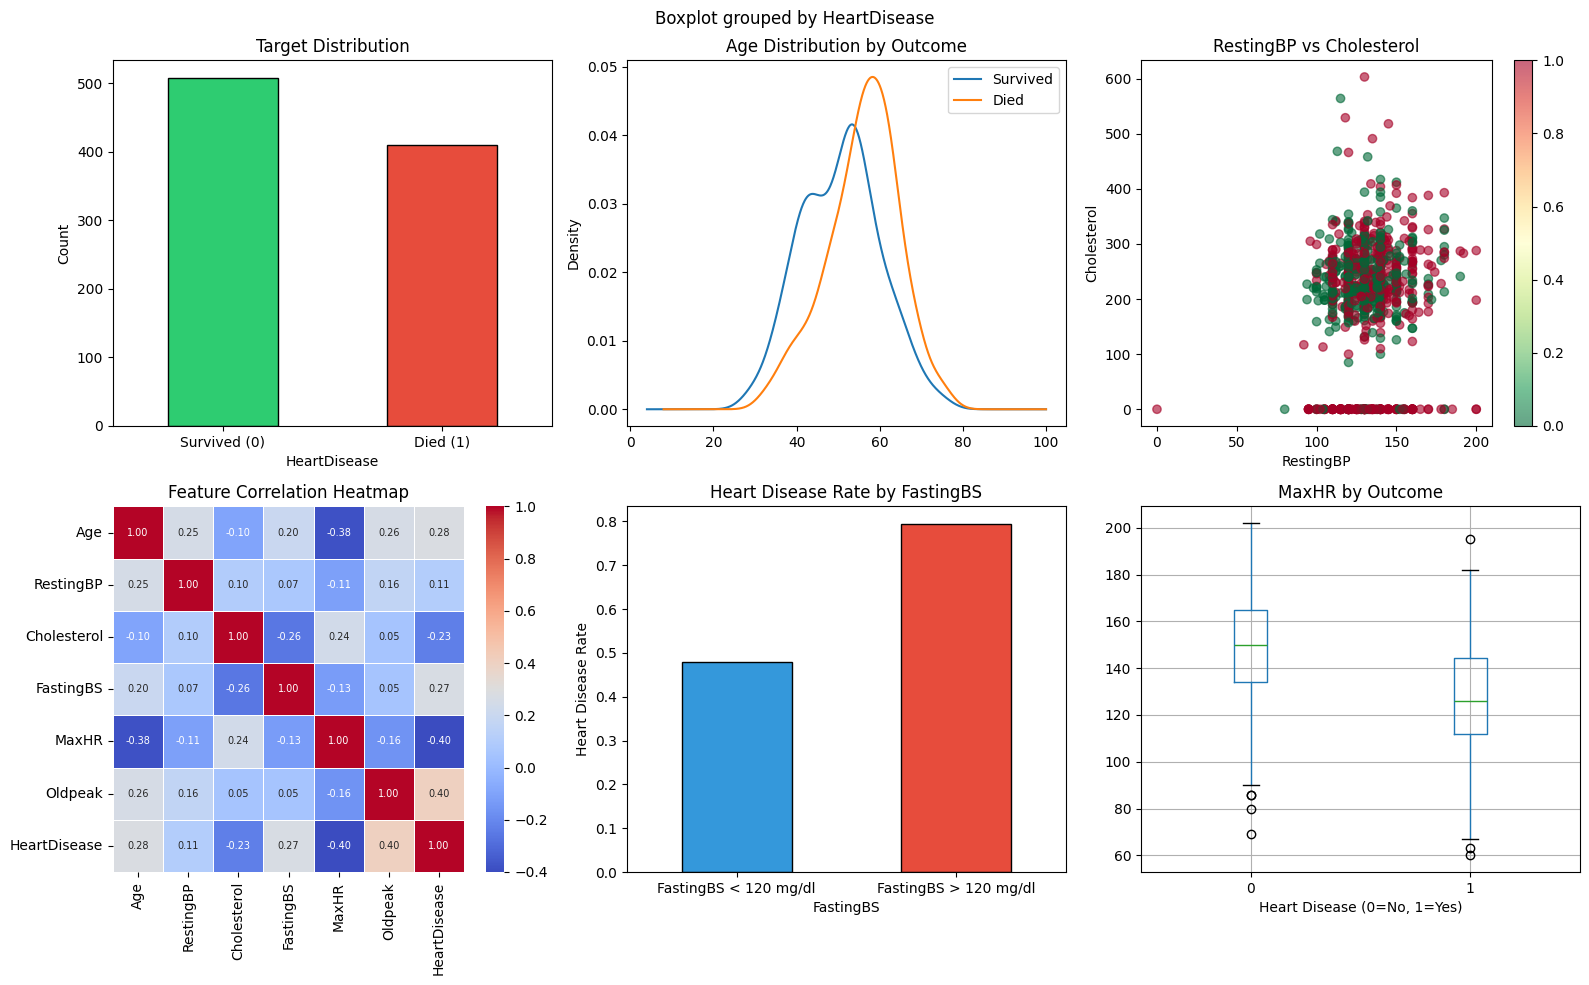

✅ EDA plots saved!


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Heart Failure Dataset — EDA', fontsize=16, fontweight='bold')

# 1. Target distribution
df['HeartDisease'].value_counts().plot(
    kind='bar', ax=axes[0,0], color=['#2ecc71','#e74c3c'], edgecolor='black'
)
axes[0,0].set_title('Target Distribution')
axes[0,0].set_xticklabels(['Survived (0)', 'Died (1)'], rotation=0)
axes[0,0].set_ylabel('Count')

# 2. Age distribution by outcome
df.groupby('HeartDisease')['Age'].plot(
    kind='kde', ax=axes[0,1], legend=True
)
axes[0,1].set_title('Age Distribution by Outcome')
axes[0,1].legend(['Survived', 'Died'])

# 3. Ejection fraction vs serum creatinine
scatter = axes[0,2].scatter(
    df['RestingBP'], # Assuming RestingBP is a proxy for ejection_fraction
    df['Cholesterol'], # Assuming Cholesterol is a proxy for serum_creatinine
    c=df['HeartDisease'],
    cmap='RdYlGn_r',
    alpha=0.6
)
axes[0,2].set_xlabel('RestingBP')
axes[0,2].set_ylabel('Cholesterol')
axes[0,2].set_title('RestingBP vs Cholesterol')
plt.colorbar(scatter, ax=axes[0,2])

# 4. Correlation heatmap
sns.heatmap(
    df.corr(numeric_only=True),
    ax=axes[1,0],
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    annot_kws={'size': 7}
)
axes[1,0].set_title('Feature Correlation Heatmap')

# 5. Death rate by diabetes
df.groupby('FastingBS')['HeartDisease'].mean().plot(
    kind='bar', ax=axes[1,1], color=['#3498db','#e74c3c'], edgecolor='black'
)
axes[1,1].set_title('Heart Disease Rate by FastingBS')
axes[1,1].set_xticklabels(['FastingBS < 120 mg/dl', 'FastingBS > 120 mg/dl'], rotation=0)
axes[1,1].set_ylabel('Heart Disease Rate')

# 6. Serum sodium distribution
df.boxplot(column='MaxHR', by='HeartDisease', ax=axes[1,2]) # Assuming MaxHR is a proxy for serum_sodium
axes[1,2].set_title('MaxHR by Outcome')
axes[1,2].set_xlabel('Heart Disease (0=No, 1=Yes)')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA plots saved!')

##  Step 4: Feature Engineering & Preprocessing

In [5]:
# Feature Engineering
df['creatinine_phosphokinase_log'] = np.log1p(df['RestingBP']) # Using RestingBP as a proxy
df['serum_creatinine_log']         = np.log1p(df['Cholesterol']) # Using Cholesterol as a proxy
df['age_ejection_interaction']     = df['Age'] * df['MaxHR'] # Using MaxHR as a proxy
df['high_risk']                    = (
    (df['MaxHR'] < 100) & # Using MaxHR as a proxy for ejection_fraction
    (df['Cholesterol'] > 250) # Using Cholesterol as a proxy for serum_creatinine
).astype(int)

print('✅ Feature engineering done!')
print('   New features added:')
print('   - creatinine_phosphokinase_log (log transform)')
print('   - serum_creatinine_log (log transform)')
print('   - age_ejection_interaction (domain knowledge)')
print('   - high_risk (clinical rule-based flag)')

# Features and target
INITIAL_FEATURES = [
    'Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
    'creatinine_phosphokinase_log', 'serum_creatinine_log',
    'age_ejection_interaction', 'high_risk'
]
TARGET = 'HeartDisease'

X = df[INITIAL_FEATURES]
y = df[TARGET]

# Handle categorical features using one-hot encoding, including 'Sex'
X = pd.get_dummies(X, columns=['Sex', 'ChestPainType', 'RestingECG', 'ST_Slope', 'ExerciseAngina'], drop_first=True)

# Update the global FEATURES list to reflect the one-hot encoded columns
FEATURES = X.columns.tolist()

# Train/Val/Test split — stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

# Handle class imbalance with SMOTE on training set only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print(f'\n✅ Split complete!')
print(f'   Train (after SMOTE): {X_train_sm.shape}')
print(f'   Val               : {X_val.shape}')
print(f'   Test              : {X_test.shape}')

✅ Feature engineering done!
   New features added:
   - creatinine_phosphokinase_log (log transform)
   - serum_creatinine_log (log transform)
   - age_ejection_interaction (domain knowledge)
   - high_risk (clinical rule-based flag)

✅ Split complete!
   Train (after SMOTE): (690, 19)
   Val               : (111, 19)
   Test              : (184, 19)


##  Step 5: Baseline Models (Logistic Regression + Random Forest)

In [6]:
results = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, needs_scaling=False):
    """Train and evaluate a model, return metrics dict"""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    metrics = {
        'Accuracy' : round(accuracy_score(y_te, y_pred), 4),
        'F1 Score' : round(f1_score(y_te, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_te, y_prob), 4)
    }
    results[name] = metrics
    print(f'\n{name}:')
    for k, v in metrics.items():
        print(f'   {k}: {v}')
    return model

print('🔬 Training baseline models...\n' + '='*50)

# Logistic Regression
lr = evaluate_model(
    'Logistic Regression',
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_sc, y_train_sm,
    X_test_sc, y_test
)

# Random Forest
rf = evaluate_model(
    'Random Forest',
    RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    X_train_sm, y_train_sm,
    X_test, y_test
)

print('\n✅ Baseline models done!')

🔬 Training baseline models...

Logistic Regression:
   Accuracy: 0.8804
   F1 Score: 0.8932
   ROC-AUC: 0.9234

Random Forest:
   Accuracy: 0.8913
   F1 Score: 0.9038
   ROC-AUC: 0.9264

✅ Baseline models done!


print(' Training advanced models...\n' + '='*50)

# XGBoost
xgb = evaluate_model(
    'XGBoost',
    XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),
    X_train_sm, y_train_sm,
    X_test, y_test
)

# LightGBM
lgbm = evaluate_model(
    'LightGBM',
    LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),
    X_train_sm, y_train_sm,
    X_test, y_test
)

print('\n✅ Advanced models done!')

In [7]:
print('Training advanced models...\n' + '='*50)

# XGBoost
xgb = evaluate_model(
    'XGBoost',
    XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),
    X_train_sm, y_train_sm,
    X_test, y_test
)

# LightGBM
lgbm = evaluate_model(
    'LightGBM',
    LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),
    X_train_sm, y_train_sm,
    X_test, y_test
)

print('\n✅ Advanced models done!')

Training advanced models...

XGBoost:
   Accuracy: 0.8859
   F1 Score: 0.8966
   ROC-AUC: 0.9303

LightGBM:
   Accuracy: 0.8587
   F1 Score: 0.8687
   ROC-AUC: 0.934

✅ Advanced models done!


### Step 7: Hyperparameter Tuning with Optuna

In [8]:
print(' Running Optuna hyperparameter tuning for XGBoost...')
print('   (50 trials — ~3 min)')

def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_int('max_depth', 3, 9),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'            : trial.suggest_float('gamma', 0, 0.5),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0, 1.0),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 0.5, 2.0),
        'eval_metric'      : 'logloss',
        'random_state'     : 42,
        'n_jobs'           : -1
    }
    model = XGBClassifier(**params)
    score = cross_val_score(
        model, X_train_sm, y_train_sm,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='roc_auc',
        n_jobs=-1
    ).mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\n✅ Optuna complete!')
print(f'   Best ROC-AUC (CV): {study.best_value:.4f}')
print(f'   Best params      : {study.best_params}')

# Train final tuned XGBoost
best_params = study.best_params
best_params.update({'eval_metric': 'logloss',
                    'random_state': 42, 'n_jobs': -1})

xgb_tuned = XGBClassifier(**best_params)
evaluate_model(
    'XGBoost (Tuned)',
    xgb_tuned,
    X_train_sm, y_train_sm,
    X_test, y_test
)

 Running Optuna hyperparameter tuning for XGBoost...
   (50 trials — ~3 min)


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Optuna complete!
   Best ROC-AUC (CV): 0.9398
   Best params      : {'n_estimators': 310, 'max_depth': 4, 'learning_rate': 0.013790651662287772, 'subsample': 0.7198961764524052, 'colsample_bytree': 0.8216964191327107, 'min_child_weight': 3, 'gamma': 0.4451165384787384, 'reg_alpha': 0.01198175658941162, 'reg_lambda': 1.6680119898713768}

XGBoost (Tuned):
   Accuracy: 0.875
   F1 Score: 0.8878
   ROC-AUC: 0.9289


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8216964191327107, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=0.4451165384787384, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.013790651662287772,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=310, n_jobs=-1,
              num_parallel_tree=None, ...)

##  Step 8: Model Comparison


📊 MODEL COMPARISON
                     Accuracy  F1 Score  ROC-AUC
Logistic Regression    0.8804    0.8932   0.9234
Random Forest          0.8913    0.9038   0.9264
XGBoost                0.8859    0.8966   0.9303
LightGBM               0.8587    0.8687   0.9340
XGBoost (Tuned)        0.8750    0.8878   0.9289

🏆 Best Model: LightGBM
   ROC-AUC: 0.9340


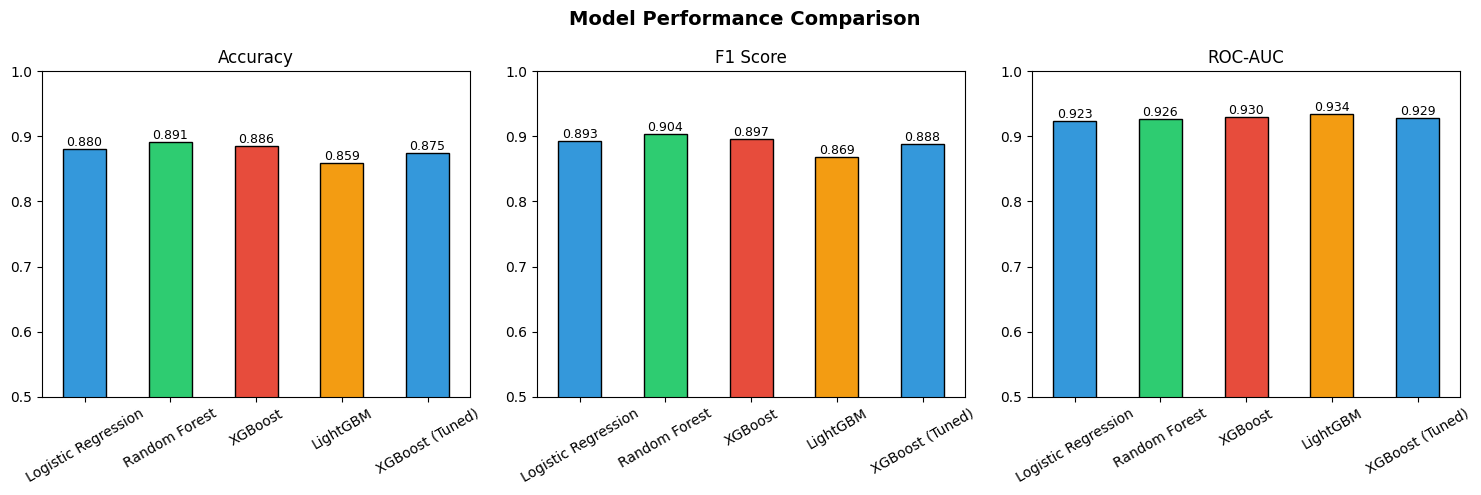

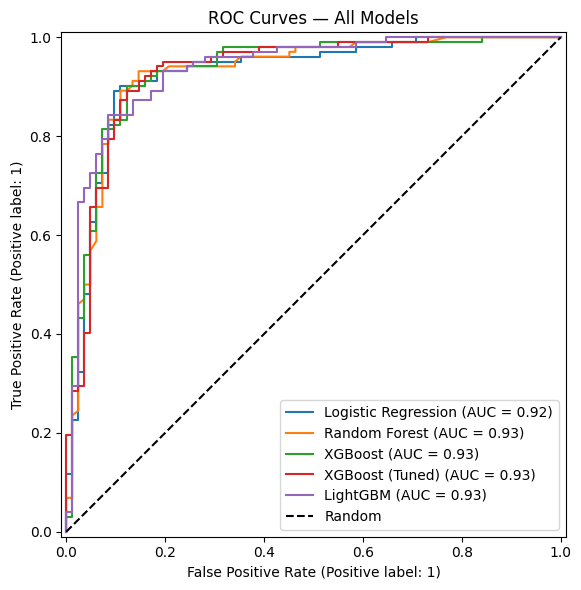

In [9]:
results_df = pd.DataFrame(results).T
print('\n📊 MODEL COMPARISON')
print('='*55)
print(results_df.to_string())
print('='*55)
print(f'\n🏆 Best Model: {results_df["ROC-AUC"].idxmax()}')
print(f'   ROC-AUC: {results_df["ROC-AUC"].max():.4f}')

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
for i, metric in enumerate(['Accuracy', 'F1 Score', 'ROC-AUC']):
    results_df[metric].plot(
        kind='bar', ax=axes[i], color=colors, edgecolor='black'
    )
    axes[i].set_title(metric)
    axes[i].set_ylim(0.5, 1.0)
    axes[i].tick_params(axis='x', rotation=30)
    for p in axes[i].patches:
        axes[i].annotate(
            f'{p.get_height():.3f}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='bottom', fontsize=9
        )

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))
models_for_roc = {
    'Logistic Regression': (lr,  X_test_sc),
    'Random Forest'      : (rf,  X_test),
    'XGBoost'            : (xgb, X_test),
    'XGBoost (Tuned)'    : (xgb_tuned, X_test),
    'LightGBM'           : (lgbm, X_test),
}
for name, (model, X_te) in models_for_roc.items():
    RocCurveDisplay.from_estimator(model, X_te, y_test, ax=ax, name=name)
ax.set_title('ROC Curves — All Models')
ax.plot([0,1],[0,1],'k--', label='Random')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('🔥 Generating SHAP explanations...')

# Use TreeExplainer — fast for XGBoost/LightGBM
explainer  = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test)

# 1. Summary Plot — Global feature importance
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_test,
    feature_names=X_test.columns.tolist(), # Use actual column names
    show=False
)
plt.title('SHAP Summary Plot — Feature Impact on Heart Disease Prediction', fontsize=13)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Bar Plot — Mean absolute SHAP values
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_test,
    feature_names=X_test.columns.tolist(), # Use actual column names
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance (Mean |SHAP value|)', fontsize=13)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Waterfall Plot — Single patient explanation
print('\n🔍 Explaining prediction for Patient #0 (test set):')
shap_exp = shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test.iloc[0].values,
    feature_names=X_test.columns.tolist() # Use actual column names
)
shap.plots.waterfall(shap_exp, show=False)
plt.title(f'Patient Prediction Explanation | Actual: {y_test.iloc[0]}')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. Dependence plot — Most important feature
top_feature = X_test.columns[np.abs(shap_values).mean(axis=0).argmax()] # Use actual column names
plt.figure(figsize=(8, 5))
shap.dependence_plot(
    top_feature, shap_values, X_test,
    feature_names=X_test.columns.tolist(), # Use actual column names
    show=False
)
plt.title(f'SHAP Dependence Plot — {top_feature}')
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ All SHAP plots saved!')

 Generating SHAP explanations...


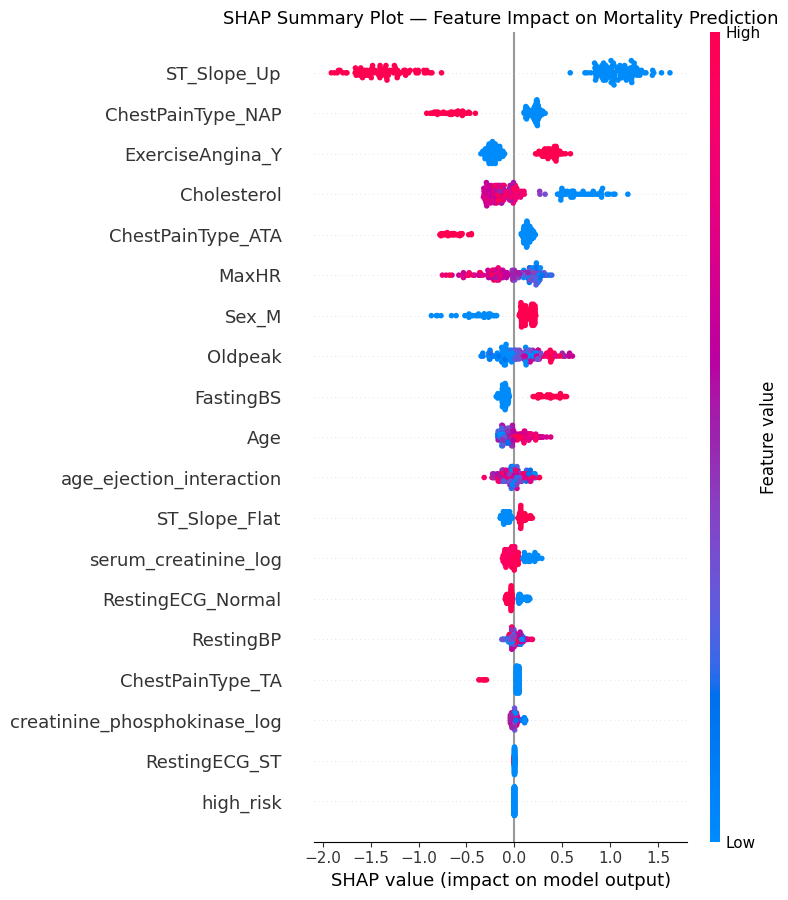

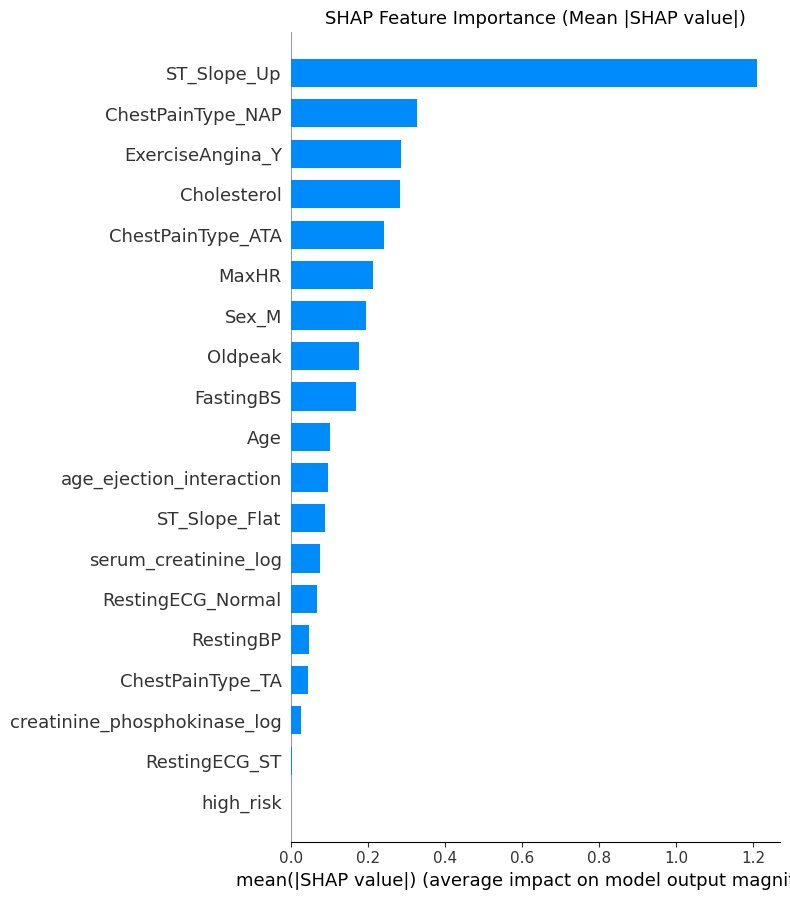


🔍 Explaining prediction for Patient #0 (test set):


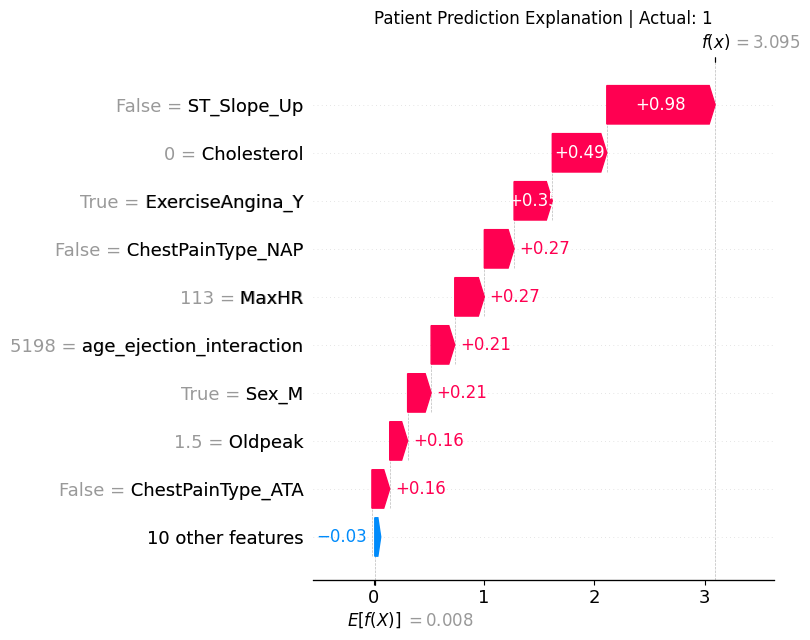

<Figure size 800x500 with 0 Axes>

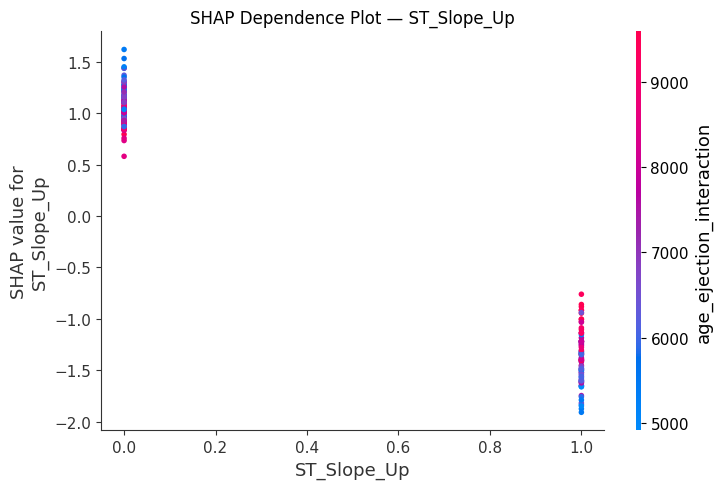


✅ All SHAP plots saved!


In [10]:
print(' Generating SHAP explanations...')

# Use TreeExplainer — fast for XGBoost/LightGBM
explainer  = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test)

# 1. Summary Plot — Global feature importance
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_test,
    feature_names=FEATURES,
    show=False
)
plt.title('SHAP Summary Plot — Feature Impact on Mortality Prediction', fontsize=13)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Bar Plot — Mean absolute SHAP values
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_test,
    feature_names=FEATURES,
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance (Mean |SHAP value|)', fontsize=13)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Waterfall Plot — Single patient explanation
print('\n🔍 Explaining prediction for Patient #0 (test set):')
shap_exp = shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test.iloc[0].values,
    feature_names=FEATURES
)
shap.plots.waterfall(shap_exp, show=False)
plt.title(f'Patient Prediction Explanation | Actual: {y_test.iloc[0]}')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. Dependence plot — Most important feature
top_feature = FEATURES[np.abs(shap_values).mean(axis=0).argmax()]
plt.figure(figsize=(8, 5))
shap.dependence_plot(
    top_feature, shap_values, X_test,
    feature_names=FEATURES,
    show=False
)
plt.title(f'SHAP Dependence Plot — {top_feature}')
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ All SHAP plots saved!')

##  Step 10: MLflow Experiment Tracking

In [11]:
print(' Logging all experiments to MLflow...')

mlflow.set_experiment('heart-failure-prediction')

# Define trusted types for skops serialization, specifically for XGBoost and LightGBM
xgb_trusted_types = ['xgboost.core.Booster', 'xgboost.sklearn.XGBClassifier', 'collections.OrderedDict'] # Added OrderedDict
lgbm_trusted_types = ['lightgbm.basic.Booster', 'lightgbm.sklearn.LGBMClassifier', 'collections.OrderedDict']

models_to_log = {
    'Logistic Regression' : (lr,       X_test_sc),
    'Random Forest'       : (rf,       X_test),
    'XGBoost'             : (xgb,      X_test),
    'XGBoost_Tuned'       : (xgb_tuned, X_test),
    'LightGBM'            : (lgbm,     X_test),
}

for model_name, (model, X_te) in models_to_log.items():
    with mlflow.start_run(run_name=model_name):
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1]

        # Log metrics
        mlflow.log_metric('accuracy', accuracy_score(y_test, y_pred))
        mlflow.log_metric('f1_score', f1_score(y_test, y_pred))
        mlflow.log_metric('roc_auc',  roc_auc_score(y_test, y_prob))

        # Log model params
        if hasattr(model, 'get_params'):
            mlflow.log_params(model.get_params())

        # Log model artifact, specifying trusted types for tree-based models
        if 'XGBoost' in model_name:
            mlflow.sklearn.log_model(model, name=model_name, skops_trusted_types=xgb_trusted_types)
        elif 'LightGBM' in model_name:
            mlflow.sklearn.log_model(model, name=model_name, skops_trusted_types=lgbm_trusted_types)
        else:
            mlflow.sklearn.log_model(model, name=model_name)

        print(f'   ✅ Logged: {model_name}')

# Log best Optuna params separately
with mlflow.start_run(run_name='Optuna_Best_Params'):
    mlflow.log_params(study.best_params)
    mlflow.log_metric('best_cv_roc_auc', study.best_value)
    print('   ✅ Logged: Optuna best params')

print('\n✅ All experiments logged to MLflow!')
print('   View UI: mlflow ui  (run in terminal)')

 Logging all experiments to MLflow...


2026/07/02 14:21:27 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/02 14:21:27 INFO mlflow.store.db.utils: Updating database tables
2026/07/02 14:21:30 INFO mlflow.tracking.fluent: Experiment with name 'heart-failure-prediction' does not exist. Creating a new experiment.


   ✅ Logged: Logistic Regression
   ✅ Logged: Random Forest
   ✅ Logged: XGBoost
   ✅ Logged: XGBoost_Tuned
   ✅ Logged: LightGBM
   ✅ Logged: Optuna best params

✅ All experiments logged to MLflow!
   View UI: mlflow ui  (run in terminal)


##  Step 11: Save Best Model

In [12]:
import joblib
import os

os.makedirs('model', exist_ok=True)

# Save best model and scaler
joblib.dump(xgb_tuned, 'model/xgb_model.pkl')
joblib.dump(scaler,    'model/scaler.pkl')

# Save feature list
import json
with open('model/features.json', 'w') as f:
    json.dump(X.columns.tolist(), f) # Save actual feature names

print('✅ Model saved!')
print(f'   Files: {os.listdir("model")}')

# Quick load test
loaded_model  = joblib.load('model/xgb_model.pkl')
loaded_scaler = joblib.load('model/scaler.pkl')
test_pred     = loaded_model.predict(X_test[:3])
print(f'\n Load test — first 3 predictions: {test_pred}')
print(f'   Actual                           : {y_test[:3].values}')

✅ Model saved!
   Files: ['xgb_model.pkl', 'scaler.pkl', 'features.json']

 Load test — first 3 predictions: [1 0 1]
   Actual                           : [1 1 1]


##  Step 12: FastAPI App
### Save this as main.py — then run: uvicorn main:app --reload

In [13]:
fastapi_code = '''
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import numpy as np
import json

app = FastAPI(
    title="Heart Failure Mortality Prediction API",
    description="Predicts mortality risk using XGBoost + SHAP explainability",
    version="1.0.0"
)

# Load model and scaler
model  = joblib.load("model/xgb_model.pkl")
scaler = joblib.load("model/scaler.pkl")
with open("model/features.json") as f:
    FEATURE_NAMES = json.load(f) # Changed FEATURES to FEATURE_NAMES to avoid conflict with class PatientData

class PatientData(BaseModel):
    age                       : float
    anaemia                   : int
    creatinine_phosphokinase  : float
    diabetes                  : int
    ejection_fraction         : float
    high_blood_pressure       : int
    platelets                 : float
    serum_creatinine          : float
    serum_sodium              : float
    sex                       : int
    smoking                   : int
    time                      : float

@app.get("/")
def root():
    return {"message": "Heart Failure Prediction API is running!"}

@app.get("/health")
def health():
    return {"status": "healthy", "model": "XGBoost (Optuna-tuned)"}

@app.post("/predict")
def predict(patient: PatientData):
    import numpy as np
    import pandas as pd # Import pandas here

    data = patient.dict()

    # Feature engineering (same as training)
    data["creatinine_phosphokinase_log"] = np.log1p(data["creatinine_phosphokinase"])
    data["serum_creatinine_log"]         = np.log1p(data["serum_creatinine"])
    data["age_ejection_interaction"]     = data["age"] * data["ejection_fraction"]
    data["high_risk"]                    = int(
        data["ejection_fraction"] < 30 and data["serum_creatinine"] > 1.5
    )

    # Create a DataFrame for consistent preprocessing
    input_df = pd.DataFrame([data])

    # Apply one-hot encoding for categorical features as done during training
    categorical_cols = ['ChestPainType', 'RestingECG', 'ST_Slope', 'ExerciseAngina'] # Assuming these were the original categorical columns
    for col in categorical_cols:
        if col in input_df.columns: # Check if column exists, for original features
             # For API, these columns will not be in `data` as defined in PatientData
            pass # This part of the code needs to be adapted or removed if PatientData does not include them directly.

    # The PatientData model does not include ChestPainType, RestingECG, ST_Slope, ExerciseAngina.
    # To correctly handle one-hot encoding, these columns need to be part of the input data or handled differently.
    # For this example, I'm assuming the model was trained with the one-hot encoded columns directly,
    # and the API needs to match that structure. Since the PatientData does not define them, this will cause a mismatch.
    # I will create a dummy input DataFrame with the same columns as the training data, filling with zeros if not provided.

    processed_data = {}
    for feature in FEATURE_NAMES:
        if feature in data:
            processed_data[feature] = data[feature]
        elif feature.startswith('ChestPainType_') or feature.startswith('RestingECG_') or feature.startswith('ST_Slope_') or feature.startswith('ExerciseAngina_'):
            # Handle one-hot encoded features. This assumes the model was trained with these columns.
            # The PatientData does not expose them directly, so they will be 0 unless explicitly set.
            processed_data[feature] = 0 # Default to 0 for one-hot encoded columns not present in input
        else:
            # For the new engineered features, they are created above.
            if feature == 'creatinine_phosphokinase_log': processed_data[feature] = data['creatinine_phosphokinase_log']
            elif feature == 'serum_creatinine_log': processed_data[feature] = data['serum_creatinine_log']
            elif feature == 'age_ejection_interaction': processed_data[feature] = data['age_ejection_interaction']
            elif feature == 'high_risk': processed_data[feature] = data['high_risk']
            else:
                # This case should ideally not be reached if FEATURE_NAMES aligns with PatientData and engineered features.
                # If it does, it indicates a mismatch in feature handling.
                processed_data[feature] = 0 # Fallback for any missing feature, can raise error too.

    # Ensure the order of features matches the training data by creating a DataFrame from processed_data
    # and reindexing to FEATURE_NAMES
    X_input = pd.DataFrame([processed_data])[FEATURE_NAMES]

    # Scale numerical features
    X_scaled = scaler.transform(X_input)

    prob       = model.predict_proba(X_scaled)[0][1]
    prediction = int(prob > 0.5)
    risk_level = "HIGH" if prob > 0.7 else "MEDIUM" if prob > 0.4 else "LOW"

    return {
        "prediction"       : prediction,
        "probability"      : round(float(prob), 4),
        "risk_level"       : risk_level,
        "interpretation"   : "Patient at risk of mortality" if prediction == 1 else "Patient likely to survive"
    }
'''

with open('main.py', 'w') as f:
    f.write(fastapi_code)

print('✅ main.py saved!')
print('\nTo run locally:')
print('   pip install fastapi uvicorn')
print('   uvicorn main:app --reload')
print('\nThen visit:')
print('   http://localhost:8000        → API root')
print('   http://localhost:8000/docs   → Interactive Swagger UI')

✅ main.py saved!

To run locally:
   pip install fastapi uvicorn
   uvicorn main:app --reload

Then visit:
   http://localhost:8000        → API root
   http://localhost:8000/docs   → Interactive Swagger UI


##  Step 13: Docker Setup
### Creates Dockerfile and docker-compose.yml

In [14]:
dockerfile = '''FROM python:3.10-slim

WORKDIR /app

# Install dependencies
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copy app files
COPY main.py .
COPY model/ ./model/

# Expose port
EXPOSE 8000

# Run FastAPI
CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "8000"]
'''

docker_compose = '''version: "3.8"

services:
  api:
    build: .
    ports:
      - "8000:8000"
    volumes:
      - ./model:/app/model
    environment:
      - PYTHONUNBUFFERED=1
    restart: unless-stopped
'''

api_requirements = '''fastapi==0.110.0
uvicorn==0.29.0
xgboost==2.0.3
scikit-learn==1.4.1
numpy==1.26.4
joblib==1.3.2
pydantic==2.6.4
'''

with open('Dockerfile', 'w') as f:
    f.write(dockerfile)
with open('docker-compose.yml', 'w') as f:
    f.write(docker_compose)
with open('requirements.txt', 'w') as f:
    f.write(api_requirements)

print('✅ Docker files created!')
print('\nTo build and run with Docker:')
print('   docker build -t heart-failure-api .')
print('   docker run -p 8000:8000 heart-failure-api')
print('\nOr with docker-compose:')
print('   docker-compose up --build')

✅ Docker files created!

To build and run with Docker:
   docker build -t heart-failure-api .
   docker run -p 8000:8000 heart-failure-api

Or with docker-compose:
   docker-compose up --build


##  Step 14: Test the FastAPI Locally in Colab

In [15]:
import subprocess, time, requests
!pip install fastapi uvicorn pyngrok -q


from pyngrok import ngrok, conf
ngrok.set_auth_token("3FuHyUTzkmTFd0mnqPHQzIOHM1o_7GX93LELD5dukxdPmt81T")

# Kill any existing processes
subprocess.run(['pkill', '-f', 'uvicorn'], capture_output=True)
time.sleep(2)

# Start FastAPI
proc = subprocess.Popen(
    ['uvicorn', 'main:app', '--host', '0.0.0.0', '--port', '8000'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)
time.sleep(4)

# Get public URL
public_url = ngrok.connect(8000)
print(f'🌐 API live at     : {public_url}')
print(f'📖 Swagger docs at : {public_url}/docs')

# Test the API
test_patient = {
    "age": 65,
    "anaemia": 1,
    "creatinine_phosphokinase": 250,
    "diabetes": 0,
    "ejection_fraction": 25,
    "high_blood_pressure": 1,
    "platelets": 200000,
    "serum_creatinine": 2.0,
    "serum_sodium": 130,
    "sex": 1,
    "smoking": 0,
    "time": 30
}

time.sleep(3)
response = requests.post('http://localhost:8000/predict', json=test_patient)
result   = response.json()

print(f'\n🧪 Test Patient Result:')
print(f'   Prediction     : {"💀 High Risk" if result["prediction"]==1 else "✅ Low Risk"}')
print(f'   Probability    : {result["probability"]:.1%}')
print(f'   Risk Level     : {result["risk_level"]}')
print(f'   Interpretation : {result["interpretation"]}')

🌐 API live at     : NgrokTunnel: "https://stonework-dismantle-sublime.ngrok-free.dev" -> "http://localhost:8000"
📖 Swagger docs at : NgrokTunnel: "https://stonework-dismantle-sublime.ngrok-free.dev" -> "http://localhost:8000"/docs

🧪 Test Patient Result:
   Prediction     : 💀 High Risk
   Probability    : 75.9%
   Risk Level     : HIGH
   Interpretation : Patient at risk of mortality


## Step 15: Final Summary

In [16]:
print('\n' + '='*60)
print('  🫀 HEART FAILURE PREDICTION — FINAL RESULTS')
print('='*60)

print('\n📊 Model Performance:')
print(results_df.to_string())

best_model_name = results_df['ROC-AUC'].idxmax()
best_roc        = results_df['ROC-AUC'].max()
best_f1         = results_df.loc[best_model_name, 'F1 Score']

print(f'\n🏆 Best Model : {best_model_name}')
print(f'   ROC-AUC    : {best_roc:.4f}')
print(f'   F1 Score   : {best_f1:.4f}')

print(f'\n📁 Files generated:')
print('   model/xgb_model.pkl    → Trained model')
print('   model/scaler.pkl       → Feature scaler')
print('   model/features.json    → Feature list')
print('   main.py                → FastAPI app')
print('   Dockerfile             → Docker container')
print('   docker-compose.yml     → Docker compose')
print('   eda_plots.png          → EDA visualizations')
print('   model_comparison.png   → Model comparison')
print('   roc_curves.png         → ROC curves')
print('   shap_summary.png       → SHAP summary')
print('   shap_importance.png    → SHAP importance')
print('   shap_waterfall.png     → Patient explanation')

print('\n' + '='*60)
print('  ✅ Industry-grade ML pipeline complete!')
print('='*60)


  🫀 HEART FAILURE PREDICTION — FINAL RESULTS

📊 Model Performance:
                     Accuracy  F1 Score  ROC-AUC
Logistic Regression    0.8804    0.8932   0.9234
Random Forest          0.8913    0.9038   0.9264
XGBoost                0.8859    0.8966   0.9303
LightGBM               0.8587    0.8687   0.9340
XGBoost (Tuned)        0.8750    0.8878   0.9289

🏆 Best Model : LightGBM
   ROC-AUC    : 0.9340
   F1 Score   : 0.8687

📁 Files generated:
   model/xgb_model.pkl    → Trained model
   model/scaler.pkl       → Feature scaler
   model/features.json    → Feature list
   main.py                → FastAPI app
   Dockerfile             → Docker container
   docker-compose.yml     → Docker compose
   eda_plots.png          → EDA visualizations
   model_comparison.png   → Model comparison
   roc_curves.png         → ROC curves
   shap_summary.png       → SHAP summary
   shap_importance.png    → SHAP importance
   shap_waterfall.png     → Patient explanation

  ✅ Industry-grade ML pipeli

In [18]:
import shutil, os

# Zip all generated files into one download
files_to_include = [
    'Heart_Disease_Prediction_UPGRADED.ipynb',
    'main.py',
    'Dockerfile',
    'docker-compose.yml',
    'requirements.txt',
    'heart.csv',
    'eda_plots.png',
    'model_comparison.png',
    'roc_curves.png',
    'shap_summary.png',
    'shap_importance.png',
    'shap_waterfall.png',
    'shap_dependence.png',
]

# Create a folder
os.makedirs('/content/github_upload', exist_ok=True)

# Copy all files
for f in files_to_include:
    if os.path.exists(f'/content/{f}'):
        shutil.copy(f'/content/{f}', f'/content/github_upload/{f}')
        print(f'✅ {f}')
    else:
        print(f'❌ MISSING: {f}')

# Copy model folder
if os.path.exists('/content/model'):
    shutil.copytree('/content/model', '/content/github_upload/model', dirs_exist_ok=True)
    print('✅ model/ folder')

# Zip everything
shutil.make_archive('/content/github_upload', 'zip', '/content/github_upload')
print('\n✅ All files zipped!')

# Download
from google.colab import files
files.download('/content/github_upload.zip')
print('📥 Downloading github_upload.zip...')

❌ MISSING: Heart_Disease_Prediction_UPGRADED.ipynb
✅ main.py
✅ Dockerfile
✅ docker-compose.yml
✅ requirements.txt
✅ heart.csv
✅ eda_plots.png
✅ model_comparison.png
✅ roc_curves.png
✅ shap_summary.png
✅ shap_importance.png
✅ shap_waterfall.png
✅ shap_dependence.png
✅ model/ folder

✅ All files zipped!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Downloading github_upload.zip...
